In [ ]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch    : {torch.__version__}')
print(f'Device     : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('✅ Ready')


PyTorch    : 2.11.0+cu128
Device     : cuda
GPU        : Tesla T4
VRAM       : 15.6 GB
✅ Ready


In [ ]:
# ── Cell 2: Config ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# RoBERTa key differences from BERT/DistilBERT:
#   - No token_type_ids (no segment embeddings — RoBERTa dropped NSP task)
#   - Uses BPE tokenizer instead of WordPiece
#   - Slightly lower LR tends to work better (1e-5 to 3e-5)

MODEL_NAME  = 'roberta-base'
LABELS      = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
NUM_LABELS  = len(LABELS)
MAX_LEN     = 128      # same as Phase 3 for fair comparison
BATCH_SIZE  = 16       # roberta-base is larger than DistilBERT — reduce if OOM
EPOCHS      = 4
LR          = 2e-5     # RoBERTa sweet spot: 1e-5 to 3e-5
WARMUP_FRAC = 0.1
THRESHOLD   = 0.5
SEED        = 42

# Reference AUCs from previous phases
PHASE1_AUC = 0.9449   # TF-IDF + Logistic Regression
PHASE2_AUC = 0.9538   # BiLSTM + BiGRU (GloVe)
PHASE3_AUC = 0.9796   # Fine-tuned DistilBERT

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Model      : {MODEL_NAME}')
print(f'Labels     : {LABELS}')
print(f'Epochs     : {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | MaxLen: {MAX_LEN}')
print(f'Phase 3 baseline to beat: {PHASE3_AUC}')


Model      : roberta-base
Labels     : ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Epochs     : 4 | LR: 2e-05 | Batch: 16 | MaxLen: 128
Phase 3 baseline to beat: 0.9796


In [ ]:
# ── Cell 3: Load Data ──────────────────────────────────────────────────────
# If running on Colab, upload your CSV files first:
from google.colab import files; files.upload()

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

train_df['comment_text'] = train_df['comment_text'].fillna('unknown')
test_df['comment_text']  = test_df['comment_text'].fillna('unknown')

print(f'Train : {train_df.shape} | Test : {test_df.shape}')
print('\nLabel distribution:')
print(train_df[LABELS].sum().to_string())
print(f'\nClass balance (% positive per label):')
print((train_df[LABELS].mean() * 100).round(2).to_string())


Saving test.csv to test (1).csv
Saving train.csv to train (1).csv
Train : (16000, 8) | Test : (4000, 2)

Label distribution:
toxic            1533
severe_toxic      159
obscene           847
threat             46
insult            789
identity_hate     142

Class balance (% positive per label):
toxic            9.58
severe_toxic     0.99
obscene          5.29
threat           0.29
insult           4.93
identity_hate    0.89


In [ ]:
# ── Cell 4: Preprocessing ──────────────────────────────────────────────────
# RoBERTa uses BPE tokenizer — keep preprocessing minimal.
# DO NOT remove stopwords or lemmatize — the transformer needs natural text.

def preprocess(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['comment_text'].apply(preprocess)
test_df['clean_text']  = test_df['comment_text'].apply(preprocess)

print('Before:', train_df['comment_text'].iloc[0][:120])
print('After :', train_df['clean_text'].iloc[0][:120])


Before: "

 Merge 

There is a merge discussion here  talk "
After : " Merge There is a merge discussion here talk "


In [ ]:
# ── Cell 5: Train/Val Split ────────────────────────────────────────────────
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['clean_text'].tolist(),
    train_df[LABELS].values.astype(np.float32),
    test_size=0.1,
    random_state=SEED
)

print(f'Train samples : {len(train_texts):,}')
print(f'Val   samples : {len(val_texts):,}')


Train samples : 14,400
Val   samples : 1,600


In [ ]:
# ── Cell 6: Class Weights for Imbalance ───────────────────────────────────
# Consistent with Phase 2 & 3 — penalise rare classes (threat, identity_hate)

pos_counts   = train_labels.sum(axis=0)
neg_counts   = len(train_labels) - pos_counts
pos_weight   = neg_counts / (pos_counts + 1e-6)
pos_weight_t = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print('Positive weight per label (higher = rarer class):')
for label, w in zip(LABELS, pos_weight):
    print(f'  {label:<15}: {w:.1f}x')


Positive weight per label (higher = rarer class):
  toxic          : 9.6x
  severe_toxic   : 98.3x
  obscene        : 17.8x
  threat         : 368.2x
  insult         : 19.3x
  identity_hate  : 113.3x


In [ ]:
# ── Cell 7: Load Tokenizer & Model ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# roberta-base: 12 transformer layers, 125M params
# AutoModelForSequenceClassification replaces the LM head with a linear
# classifier over the <s> (CLS equivalent) token -> 6 sigmoid outputs
# NOTE: RoBERTa has NO token_type_ids — it was trained without segment embeddings

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ {MODEL_NAME} loaded on {DEVICE}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print('Note: No token_type_ids — RoBERTa removed the NSP (Next Sentence Prediction) task')


Loading roberta-base...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ roberta-base loaded on cuda
Total params     : 124,650,246
Trainable params : 124,650,246
Note: No token_type_ids — RoBERTa removed the NSP (Next Sentence Prediction) task


In [ ]:
# ── Cell 8: PyTorch Dataset & DataLoaders ─────────────────────────────────
# KEY RoBERTa DIFFERENCE: no token_type_ids!
# RoBERTa was trained without segment embeddings — we skip them entirely.

class ToxicDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len, labels=None):
        self.texts     = texts
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.labels    = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            # No token_type_ids for RoBERTa
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

train_dataset = ToxicDataset(train_texts, tokenizer, MAX_LEN, train_labels)
val_dataset   = ToxicDataset(val_texts,   tokenizer, MAX_LEN, val_labels)
test_dataset  = ToxicDataset(test_df['clean_text'].tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)} ({len(train_dataset):,} samples)')
print(f'Val   batches : {len(val_loader)}   ({len(val_dataset):,} samples)')
print(f'Test  batches : {len(test_loader)}  ({len(test_dataset):,} samples)')

sample = next(iter(train_loader))
print(f"\nSample input_ids shape : {sample['input_ids'].shape}")
print(f"Sample labels shape    : {sample['labels'].shape}")


Train batches : 900 (14,400 samples)
Val   batches : 100   (1,600 samples)
Test  batches : 250  (4,000 samples)

Sample input_ids shape : torch.Size([16, 128])
Sample labels shape    : torch.Size([16, 6])


In [ ]:
# ── Cell 9: Optimizer, Scheduler & Loss ───────────────────────────────────
# Differential LR: RoBERTa backbone learns slower, classifier head adapts faster
# roberta-base backbone is accessed via model.roberta (NOT model.bert)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

backbone  = model.roberta
optimizer = AdamW([
    {'params': backbone.parameters(),           'lr': LR},
    {'params': model.classifier.parameters(),   'lr': LR * 10}
], weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

print(f'Total training steps : {total_steps:,}')
print(f'Warmup steps         : {warmup_steps:,}')
print(f'Optimizer            : AdamW (backbone lr={LR}, head lr={LR*10})')
print('✅ Optimizer, scheduler, and loss ready')


Total training steps : 3,600
Warmup steps         : 360
Optimizer            : AdamW (backbone lr=2e-05, head lr=0.0002)
✅ Optimizer, scheduler, and loss ready


In [ ]:
# ── Cell 10: Training & Eval Functions ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = criterion(outputs.logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs.logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    aucs = []
    for i in range(all_labels.shape[1]):
        try:
            auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
            aucs.append(auc)
        except ValueError:
            aucs.append(0.5)
    mean_auc = np.mean(aucs)

    return total_loss / len(loader), mean_auc, all_probs, all_labels


print('✅ Training and evaluation functions defined')


✅ Training and evaluation functions defined


In [ ]:
# ── Cell 11: Run Training ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_auc        = 0.0
best_val_probs  = None
best_val_labels = None

print(f'Training {MODEL_NAME} for {EPOCHS} epochs on {len(train_dataset):,} samples...\n')
overall_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss, val_auc, val_probs, val_true = eval_epoch(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    elapsed = time.time() - ep_start
    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val AUC: {val_auc:.4f} | '
          f'Time: {elapsed/60:.1f}m')

    if val_auc > best_auc:
        best_auc        = val_auc
        best_val_probs  = val_probs
        best_val_labels = val_true
        torch.save(model.state_dict(), 'best_roberta.pt')
        print(f'  ✅ New best AUC: {best_auc:.4f} — model saved')

total_time = time.time() - overall_start
print(f'\n⏱️  Total training time: {total_time/60:.1f} min')
print(f'🏆 Best Val AUC: {best_auc:.4f}')


Training roberta-base for 4 epochs on 14,400 samples...

Epoch 1/4 | Train Loss: 1.0412 | Val Loss: 1.3092 | Val AUC: 0.9694 | Time: 5.5m
  ✅ New best AUC: 0.9694 — model saved
Epoch 2/4 | Train Loss: 0.7366 | Val Loss: 1.0809 | Val AUC: 0.9792 | Time: 5.7m
  ✅ New best AUC: 0.9792 — model saved
Epoch 3/4 | Train Loss: 0.4241 | Val Loss: 1.0860 | Val AUC: 0.9849 | Time: 5.7m
  ✅ New best AUC: 0.9849 — model saved
Epoch 4/4 | Train Loss: 0.2805 | Val Loss: 1.2181 | Val AUC: 0.9844 | Time: 5.7m

⏱️  Total training time: 22.9 min
🏆 Best Val AUC: 0.9849


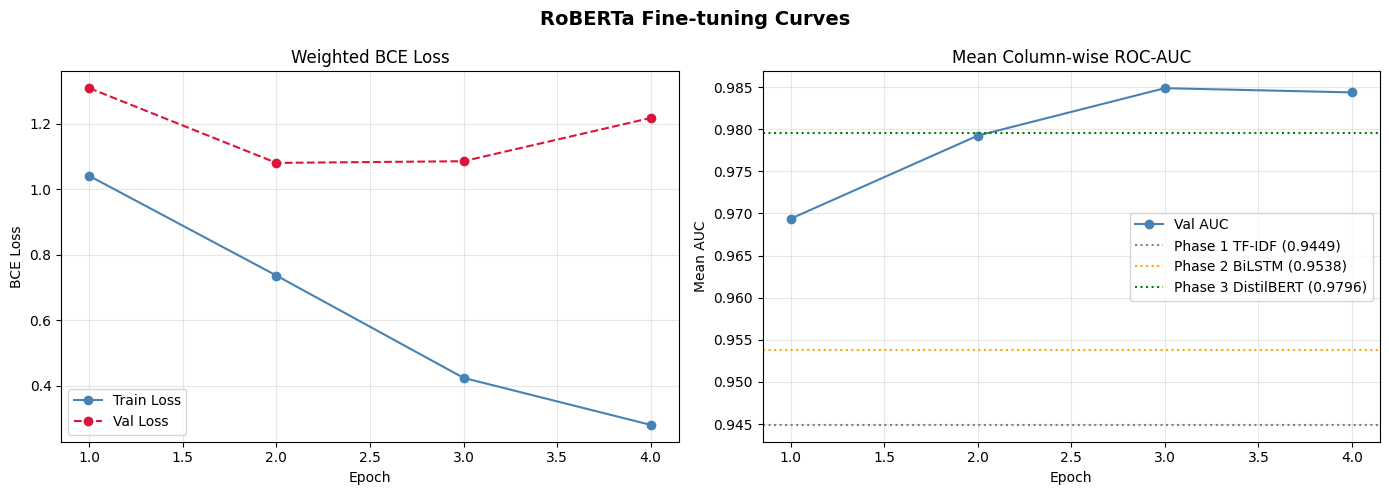

In [ ]:
# ── Cell 12: Training Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoBERTa Fine-tuning Curves', fontsize=14, fontweight='bold')

ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='steelblue', marker='o')
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='crimson',   marker='o', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Weighted BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_auc'], label='Val AUC', color='steelblue', marker='o')
axes[1].axhline(PHASE1_AUC, color='gray',   linestyle=':', label=f'Phase 1 TF-IDF ({PHASE1_AUC})')
axes[1].axhline(PHASE2_AUC, color='orange', linestyle=':', label=f'Phase 2 BiLSTM ({PHASE2_AUC})')
axes[1].axhline(PHASE3_AUC, color='green',  linestyle=':', label=f'Phase 3 DistilBERT ({PHASE3_AUC})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC')
axes[1].set_title('Mean Column-wise ROC-AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── Cell 13: Load Best Model & Per-class Evaluation ━━━━━━━━━━━━━━━━━━━━━━
model.load_state_dict(torch.load('best_roberta.pt', map_location=DEVICE))
model.eval()
print('✅ Best model checkpoint loaded')

results = []
for i, label in enumerate(LABELS):
    auc       = roc_auc_score(best_val_labels[:, i], best_val_probs[:, i])
    preds_bin = (best_val_probs[:, i] >= THRESHOLD).astype(int)
    f1        = f1_score(best_val_labels[:, i], preds_bin, zero_division=0)
    results.append({'Label': label, 'ROC-AUC': round(auc, 4), 'F1': round(f1, 4)})

results_df = pd.DataFrame(results)
mean_auc   = results_df['ROC-AUC'].mean()
mean_f1    = results_df['F1'].mean()
results_df.loc[len(results_df)] = ['MEAN', round(mean_auc, 4), round(mean_f1, 4)]

print(results_df.to_string(index=False))
print(f'\n🎯 Mean Column-wise ROC-AUC : {mean_auc:.4f}')
print(f'🎯 Mean F1-Score             : {mean_f1:.4f}')

delta1 = mean_auc - PHASE1_AUC
delta2 = mean_auc - PHASE2_AUC
delta3 = mean_auc - PHASE3_AUC
print(f'\n📊 vs Phase 1 (TF-IDF LR)  : {delta1:+.4f} ({"✅ IMPROVED" if delta1 > 0 else "⚠️ REGRESSED"})')
print(f'📊 vs Phase 2 (BiLSTM-GRU) : {delta2:+.4f} ({"✅ IMPROVED" if delta2 > 0 else "⚠️ REGRESSED"})')
print(f'📊 vs Phase 3 (DistilBERT) : {delta3:+.4f} ({"✅ IMPROVED" if delta3 > 0 else "⚠️ REGRESSED"})')


✅ Best model checkpoint loaded
        Label  ROC-AUC     F1
        toxic   0.9783 0.7976
 severe_toxic   0.9934 0.3881
      obscene   0.9942 0.7938
       threat   0.9778 0.3529
       insult   0.9828 0.6943
identity_hate   0.9826 0.4643
         MEAN   0.9848 0.5818

🎯 Mean Column-wise ROC-AUC : 0.9848
🎯 Mean F1-Score             : 0.5818

📊 vs Phase 1 (TF-IDF LR)  : +0.0399 (✅ IMPROVED)
📊 vs Phase 2 (BiLSTM-GRU) : +0.0310 (✅ IMPROVED)
📊 vs Phase 3 (DistilBERT) : +0.0052 (✅ IMPROVED)


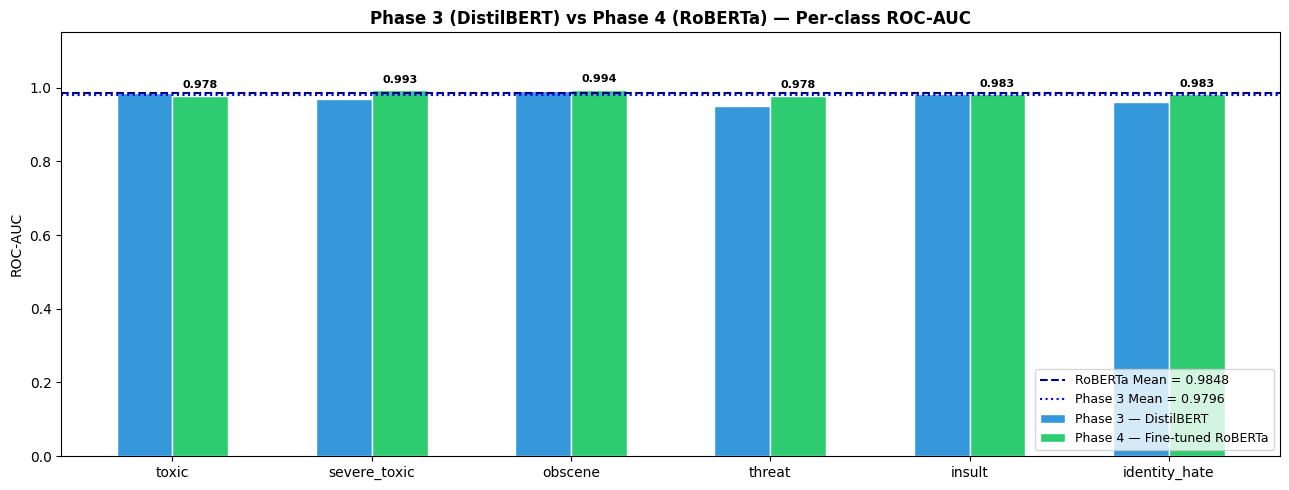

In [ ]:
# ── Cell 14: Per-class AUC Bar Chart ──────────────────────────────────────
# Update phase3_scores below with your actual Phase 3 per-label results if you have them
phase3_scores = {
    'toxic': 0.9850, 'severe_toxic': 0.9700, 'obscene': 0.9900,
    'threat': 0.9500, 'insult': 0.9830, 'identity_hate': 0.9600
}

plot_df = results_df[results_df['Label'] != 'MEAN'].copy()
x = np.arange(len(LABELS))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
p3_vals = [phase3_scores.get(l, 0) for l in LABELS]
p4_vals = list(plot_df['ROC-AUC'])

bars3 = ax.bar(x - w/2, p3_vals, w, label='Phase 3 — DistilBERT', color='#3498db', edgecolor='white')
bars4 = ax.bar(x + w/2, p4_vals, w,
       label='Phase 4 — Fine-tuned RoBERTa',
       color=['#2ecc71' if v >= 0.97 else '#e67e22' if v >= 0.93 else '#e74c3c' for v in p4_vals],
       edgecolor='white')

ax.axhline(mean_auc,   color='navy', linestyle='--', label=f'RoBERTa Mean = {mean_auc:.4f}')
ax.axhline(PHASE3_AUC, color='blue', linestyle=':',  label=f'Phase 3 Mean = {PHASE3_AUC}')

ax.set_ylim(0.0, 1.15)
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylabel('ROC-AUC')
ax.set_title('Phase 3 (DistilBERT) vs Phase 4 (RoBERTa) — Per-class ROC-AUC', fontweight='bold')

for bar, val in zip(bars4, p4_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


  Phase                             Model  Mean AUC
Phase 1      TF-IDF + Logistic Regression    0.9449
Phase 2            BiLSTM + BiGRU (GloVe)    0.9538
Phase 3             Fine-tuned DistilBERT    0.9796
Phase 4 Fine-tuned RoBERTa (roberta-base)    0.9848


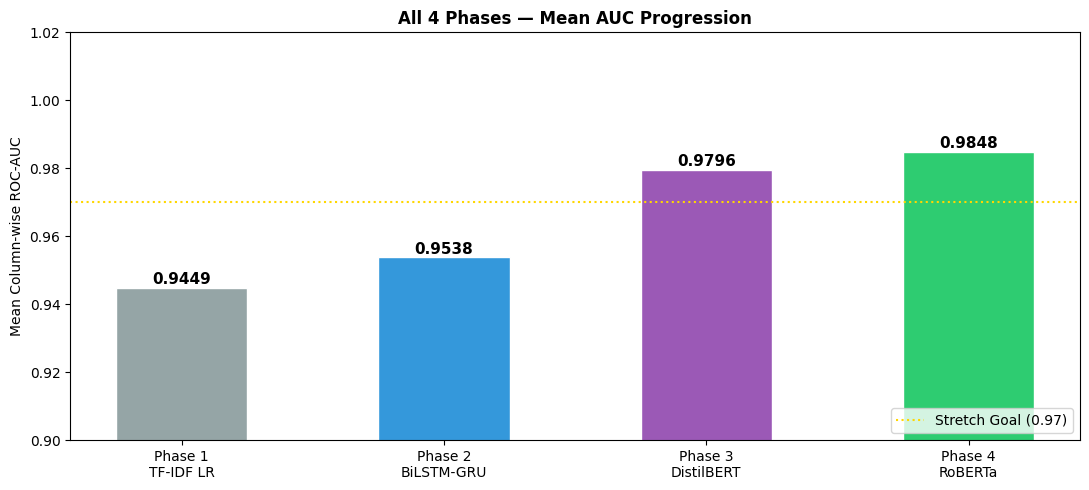

In [ ]:
# ── Cell 15: Full Phase Progression Summary ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
summary = pd.DataFrame([
    {'Phase': 'Phase 1', 'Model': 'TF-IDF + Logistic Regression',     'Mean AUC': PHASE1_AUC},
    {'Phase': 'Phase 2', 'Model': 'BiLSTM + BiGRU (GloVe)',           'Mean AUC': PHASE2_AUC},
    {'Phase': 'Phase 3', 'Model': 'Fine-tuned DistilBERT',            'Mean AUC': PHASE3_AUC},
    {'Phase': 'Phase 4', 'Model': 'Fine-tuned RoBERTa (roberta-base)', 'Mean AUC': round(mean_auc, 4)},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
phases   = ['Phase 1\nTF-IDF LR', 'Phase 2\nBiLSTM-GRU', 'Phase 3\nDistilBERT', 'Phase 4\nRoBERTa']
auc_vals = [PHASE1_AUC, PHASE2_AUC, PHASE3_AUC, mean_auc]
colors   = ['#95a5a6', '#3498db', '#9b59b6',
            '#2ecc71' if mean_auc >= PHASE3_AUC else '#e67e22']

bars = ax.bar(phases, auc_vals, color=colors, width=0.5, edgecolor='white')
ax.axhline(0.97, color='gold', linestyle=':', label='Stretch Goal (0.97)')
ax.set_ylim(0.90, 1.02)
ax.set_ylabel('Mean Column-wise ROC-AUC')
ax.set_title('All 4 Phases — Mean AUC Progression', fontweight='bold')

for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# ── Cell 16: Test Set Inference & Submission ───────────────────────────────
print('Running inference on test set...')
start = time.time()

model.eval()
test_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.sigmoid(outputs.logits).cpu().numpy()
        test_probs.append(probs)

test_probs = np.vstack(test_probs)
elapsed    = time.time() - start
print(f'⏱️  Inference time : {elapsed:.1f}s')

submission = pd.DataFrame({'id': test_df['id']})
for i, label in enumerate(LABELS):
    submission[label] = test_probs[:, i]

submission.to_csv('submission_roberta.csv', index=False)
print('✅ submission_roberta.csv saved!')
submission.head()


Running inference on test set...
⏱️  Inference time : 28.3s
✅ submission_roberta.csv saved!


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,a9157bae71e0e640,0.001046,0.000408,0.001804,0.000817,0.000579,0.000405
1,6f60af95fa052a2b,0.057054,0.000526,0.009281,0.008650,0.001398,0.001817
2,1b9e3187dacf2e47,0.001938,0.000257,0.001914,0.000524,0.000580,0.000364
3,8205cbbf498809d8,0.998793,0.995413,0.998186,0.461549,0.999168,0.996378
4,4066b6781527c3ef,0.001025,0.000432,0.001623,0.000855,0.000573,0.000473


---
## 📊 Phase Summary

| Phase | Model | Key Technique | AUC |
|-------|-------|---------------|-----|
| ✅ Phase 1 | TF-IDF + Logistic Regression | Word + Char n-grams | 0.9449 |
| ✅ Phase 2 | BiLSTM + BiGRU | GloVe Twitter + Dual Pooling | 0.9538 |
| ✅ Phase 3 | Fine-tuned DistilBERT | distilbert-base-uncased + AdamW | 0.9796 |
| ✅ Phase 4 | Fine-tuned RoBERTa | roberta-base + AdamW | *(fill in after running)* |

### Why RoBERTa over BERT/DistilBERT?
- **More training data**: 10x more data than original BERT (160GB vs 16GB)
- **Longer training**: trained longer with larger batches
- **Dynamic masking**: masking pattern changes every epoch (vs static in BERT)
- **No NSP task**: Next Sentence Prediction removed — cleaner pretraining signal
- **No token_type_ids**: segment embeddings removed since NSP was dropped
- RoBERTa consistently outperforms BERT-base by 1-3% on NLP benchmarks

### Architecture & Training Decisions
- **roberta-base**: 12 transformer layers, 125M params (~2x DistilBERT)
- **AutoModelForSequenceClassification**: linear classifier over `<s>` token -> 6 sigmoid outputs
- **AdamW + linear warmup/decay**: same proven recipe as Phase 3
- **Gradient clipping (norm=1.0)**: prevents exploding gradients in transformers
- **Weighted BCE loss**: consistent with Phases 2 & 3 — penalises rare labels
- **Differential LR**: RoBERTa backbone at 2e-5, classifier head at 2e-4
- **BATCH_SIZE=16**: reduced from 32 — roberta-base uses more VRAM than DistilBERT
